# Attestation Propagation Time Comparison: Pre-Fusaka vs Post-Fusaka

This notebook compares attestation propagation times between:
- **Pre-Fusaka**: Slots 12,344,420 - 12,394,820
- **Post-Fusaka**: Slots 13,191,650 - 13,220,450

## 1. Imports


In [17]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")


In [18]:
# Main directories and files
current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))

# Data paths
PRE_FUSAKA_PATH = "missed_slots_12344420_12394820"
POST_FUSAKA_PATH = "missed_slots_13191650_13220450"


In [19]:
# Plotting theme
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 150, "axes.titlesize": 14}
)


## 2. Load Data


In [20]:
def load_attestation_data(data_path, label):
    """Load and process attestation data from a given path."""
    # Load attestations
    atts_file = os.path.join(repo_dir, "data", data_path, "sample_atts.parquet")
    atts_df = pd.read_parquet(atts_file)
    atts_df["atts_prop_time_ms"] = atts_df["atts_arrival_time_ms"] - 4000
    
    # Load validator info
    val_file = os.path.join(repo_dir, "data", "ethseer_val_info.parquet")
    val_df = pd.read_parquet(val_file)
    
    # Join data
    df = (
        atts_df.merge(val_df, right_on="index", left_on="atts_validator", how="left")
        .drop(columns=["index"])
        .fillna({"entity": "unknown"})
    )
    
    # Group low cardinality entities
    entity_counts = df["entity"].value_counts() / len(df)
    df = df.merge(entity_counts, left_on="entity", right_index=True)
    df["entity"] = np.where(df["count"] > 0.01, df["entity"], "other")
    df = df.drop(columns=["count"])
    
    # Add period label
    df["period"] = label
    
    print(f"{label}: {len(df):,} attestations, {df['slot'].nunique():,} slots")
    return df


In [21]:
# Load both datasets
pre_df = load_attestation_data(PRE_FUSAKA_PATH, "Pre-Fusaka")
post_df = load_attestation_data(POST_FUSAKA_PATH, "Post-Fusaka")

# Combine for comparison plots
combined_df = pd.concat([pre_df, post_df], ignore_index=True)
print(f"\nCombined: {len(combined_df):,} total attestations")


Pre-Fusaka: 2,316,265 attestations, 183 slots
Post-Fusaka: 2,360,631 attestations, 205 slots

Combined: 4,676,896 total attestations


## 3. Summary Statistics Comparison


In [22]:
# Filter to positive propagation times
filtered_df = combined_df[combined_df["atts_prop_time_ms"] > 0]

# Summary statistics by period
stats = filtered_df.groupby("period")["atts_prop_time_ms"].agg([
    ("Count", "count"),
    ("Mean (ms)", "mean"),
    ("Median (ms)", "median"),
    ("Std (ms)", "std"),
    ("P25 (ms)", lambda x: x.quantile(0.25)),
    ("P75 (ms)", lambda x: x.quantile(0.75)),
    ("P95 (ms)", lambda x: x.quantile(0.95)),
    ("P99 (ms)", lambda x: x.quantile(0.99)),
]).round(1)

stats


,Count,Mean (ms),Median (ms),Std (ms),P25 (ms),P75 (ms),P95 (ms),P99 (ms)
period,,,,,,,,
Post-Fusaka,2359338,703.7,577.0,498.4,372.0,875.0,1634.0,2651.0
Pre-Fusaka,2313595,747.5,582.0,567.6,365.0,959.0,1782.0,2931.0


## 4. Propagation Time Distribution Comparison


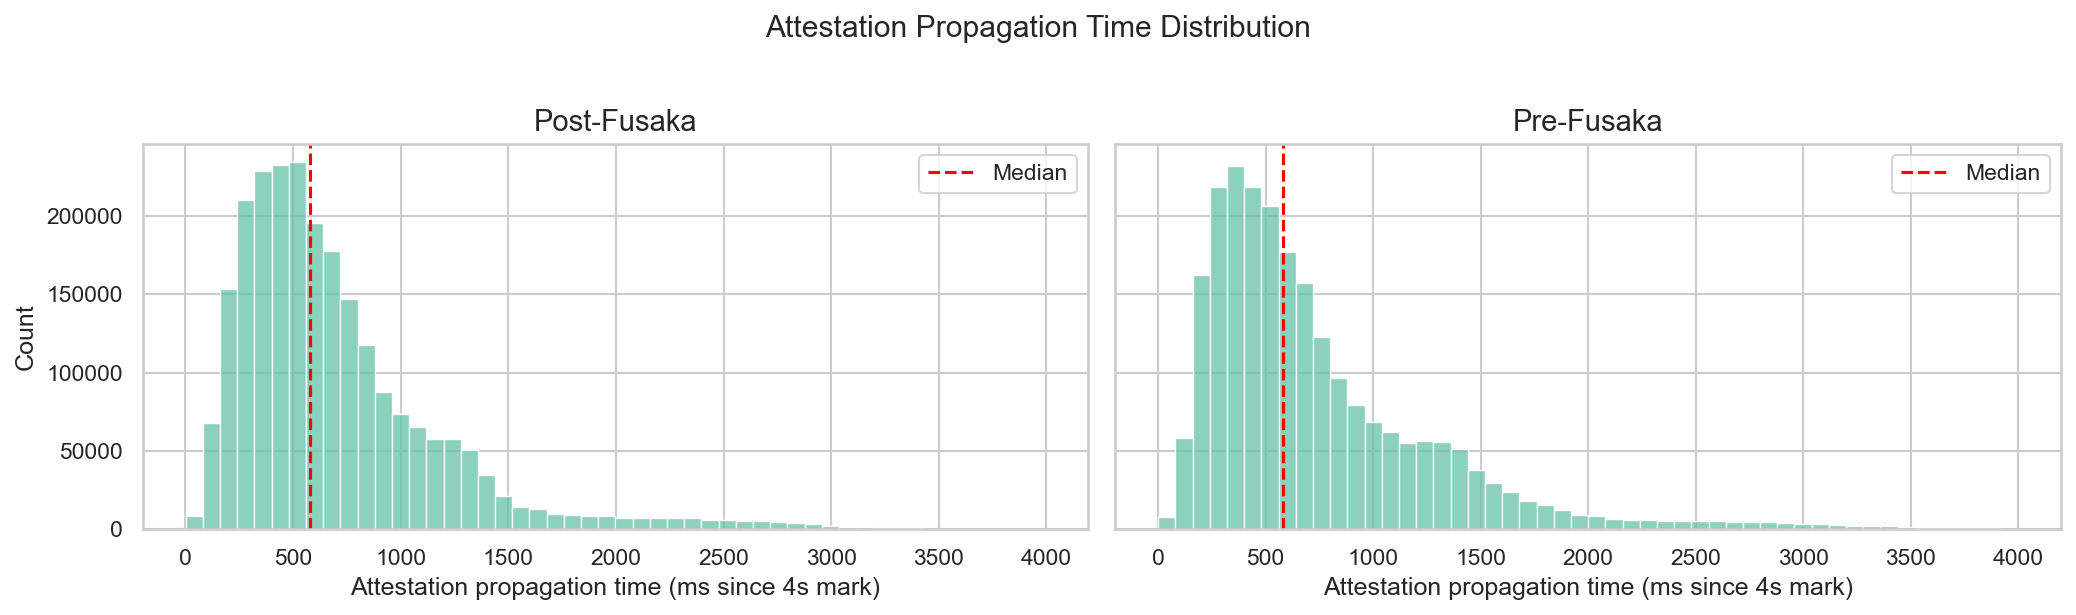

In [23]:
# Histogram comparison
temp_df = filtered_df[filtered_df["atts_prop_time_ms"].between(0, 4000)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, (period, group) in zip(axes, temp_df.groupby("period")):
    sns.histplot(data=group, x="atts_prop_time_ms", ax=ax, bins=50)
    ax.set_title(f"{period}")
    ax.set_xlabel("Attestation propagation time (ms since 4s mark)")
    ax.axvline(x=group["atts_prop_time_ms"].median(), color="red", linestyle="--", label="Median")
    ax.legend()

axes[0].set_ylabel("Count")
plt.suptitle("Attestation Propagation Time Distribution", y=1.02)
plt.tight_layout()
plt.show()


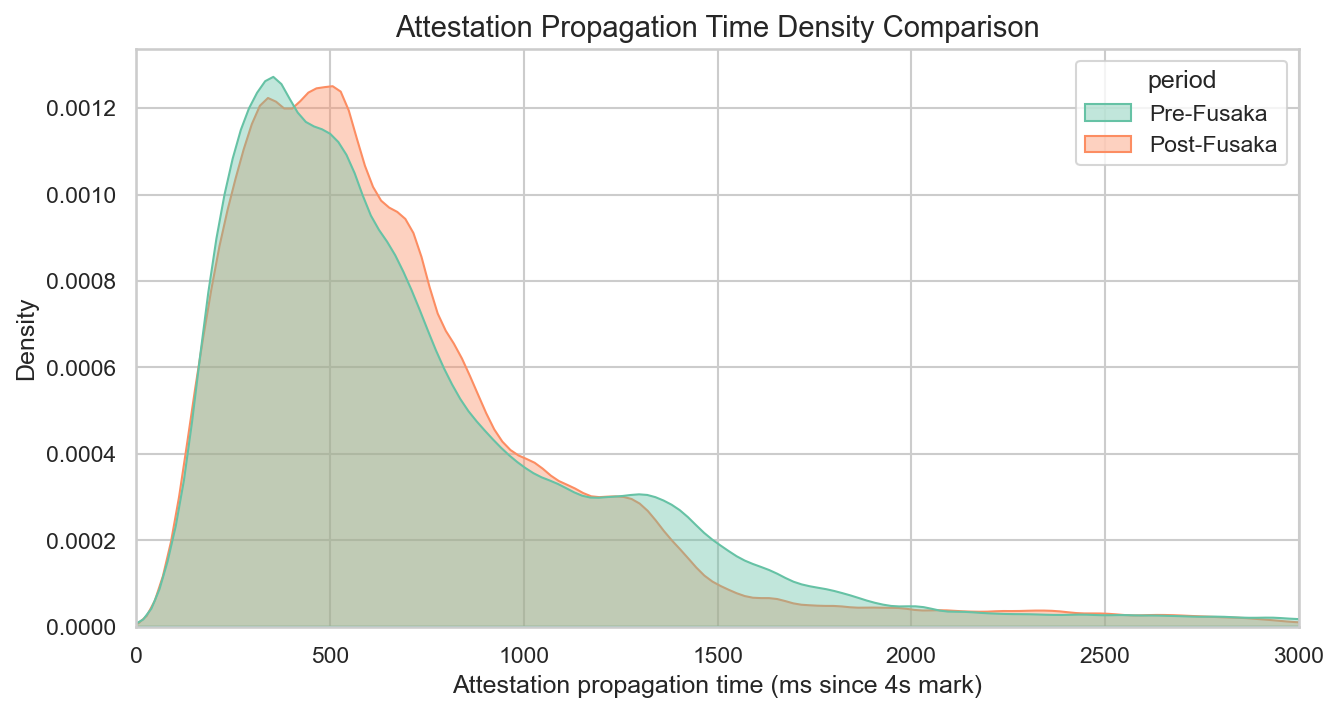

In [24]:
# Overlayed density plot for direct comparison
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=temp_df, 
    x="atts_prop_time_ms", 
    hue="period",
    fill=True, 
    alpha=0.4,
    common_norm=False
)
plt.title("Attestation Propagation Time Density Comparison")
plt.xlabel("Attestation propagation time (ms since 4s mark)")
plt.ylabel("Density")
plt.xlim(0, 3000)
plt.show()


## 5. CDF Comparison


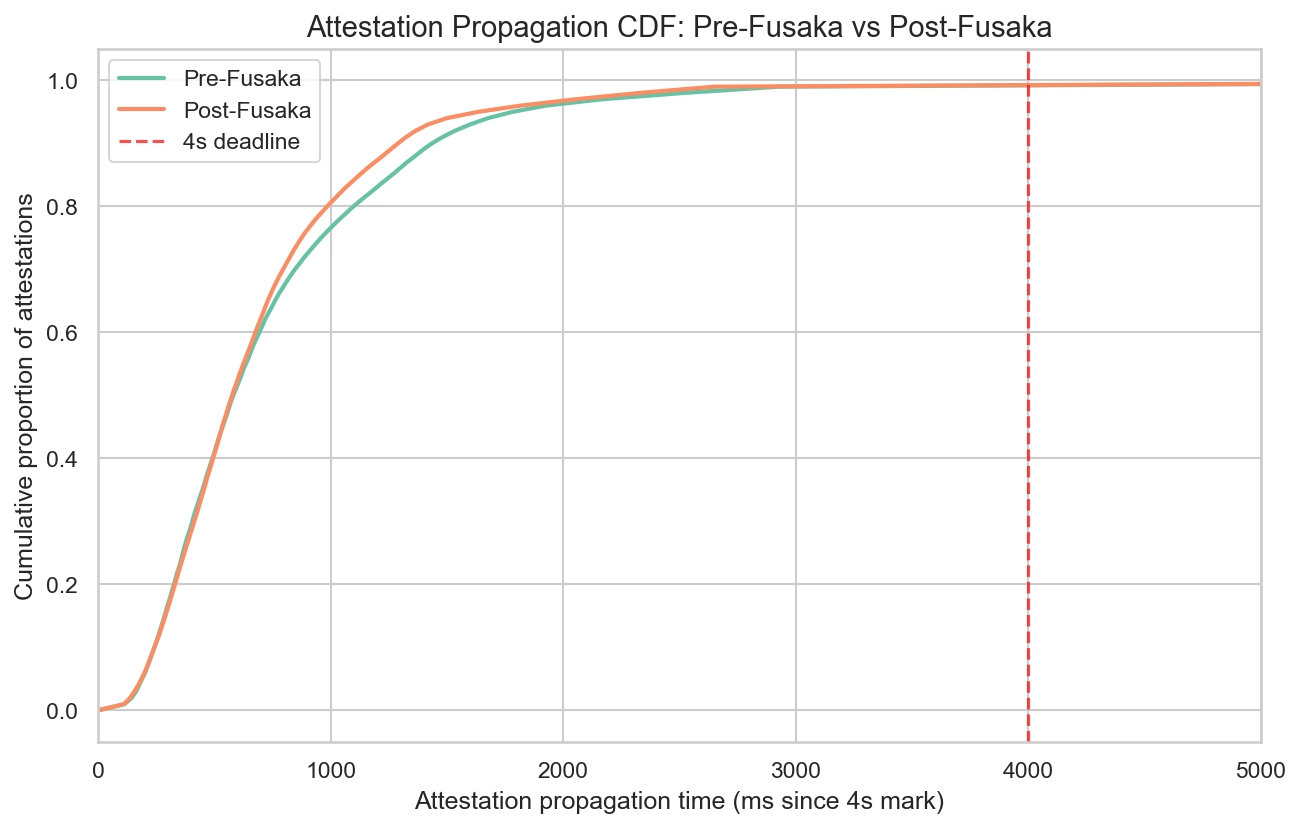

In [25]:
# Calculate CDFs for both periods
percentiles = np.arange(0, 1.01, 0.01)

cdf_data = []
for period in ["Pre-Fusaka", "Post-Fusaka"]:
    period_df = filtered_df[filtered_df["period"] == period]
    quantiles = period_df["atts_prop_time_ms"].quantile(percentiles)
    for p, q in zip(percentiles, quantiles):
        cdf_data.append({"period": period, "percentile": p, "time_ms": q})

cdf_df = pd.DataFrame(cdf_data)

# Plot CDFs
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=cdf_df, 
    x="time_ms", 
    y="percentile", 
    hue="period",
    linewidth=2
)
plt.axvline(x=4000, color="red", linestyle="--", alpha=0.7, label="4s deadline")
plt.title("Attestation Propagation CDF: Pre-Fusaka vs Post-Fusaka")
plt.xlabel("Attestation propagation time (ms since 4s mark)")
plt.ylabel("Cumulative proportion of attestations")
plt.xlim(0, 5000)
plt.legend()
plt.show()


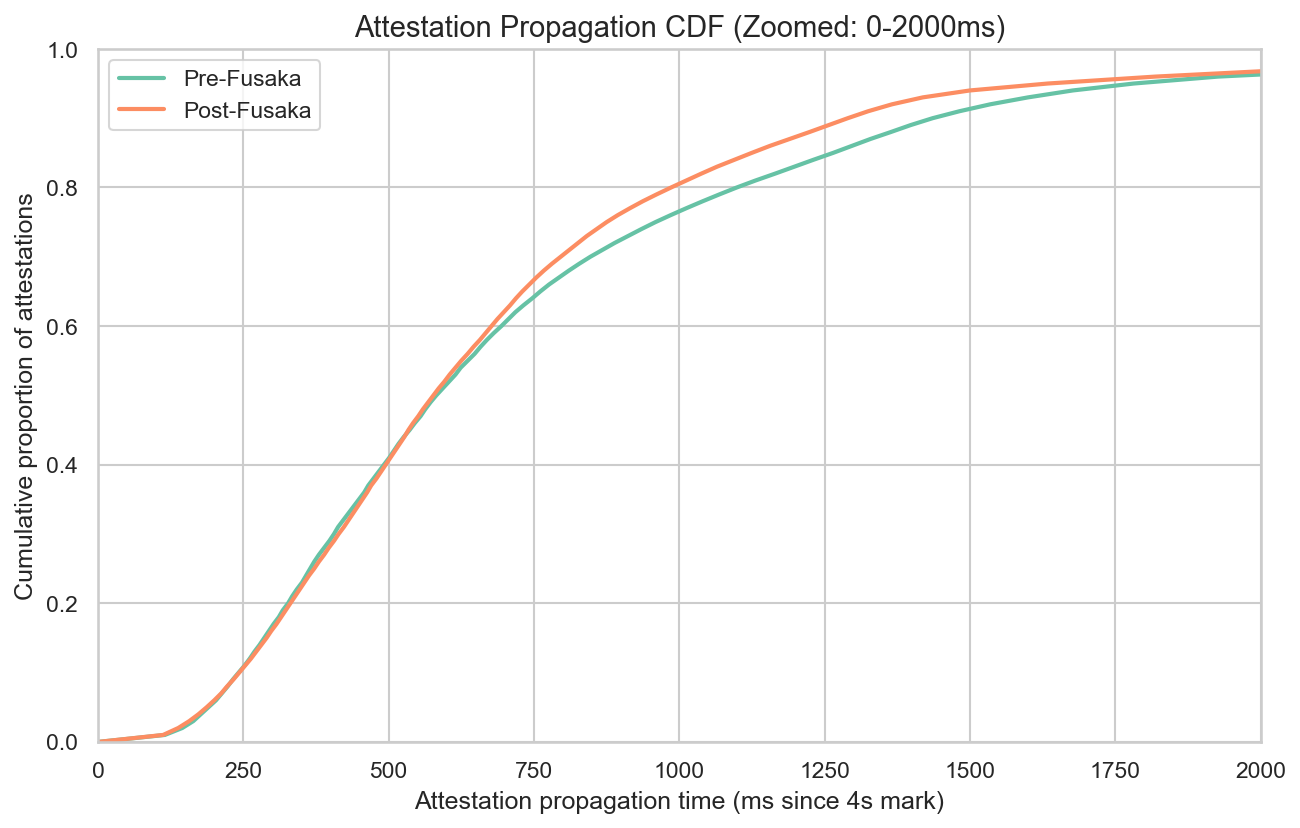

In [26]:
# Zoomed CDF - focus on 0-2000ms range
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=cdf_df, 
    x="time_ms", 
    y="percentile", 
    hue="period",
    linewidth=2
)
plt.title("Attestation Propagation CDF (Zoomed: 0-2000ms)")
plt.xlabel("Attestation propagation time (ms since 4s mark)")
plt.ylabel("Cumulative proportion of attestations")
plt.xlim(0, 2000)
plt.ylim(0, 1)
plt.legend()
plt.show()


## 6. Box Plot Comparison


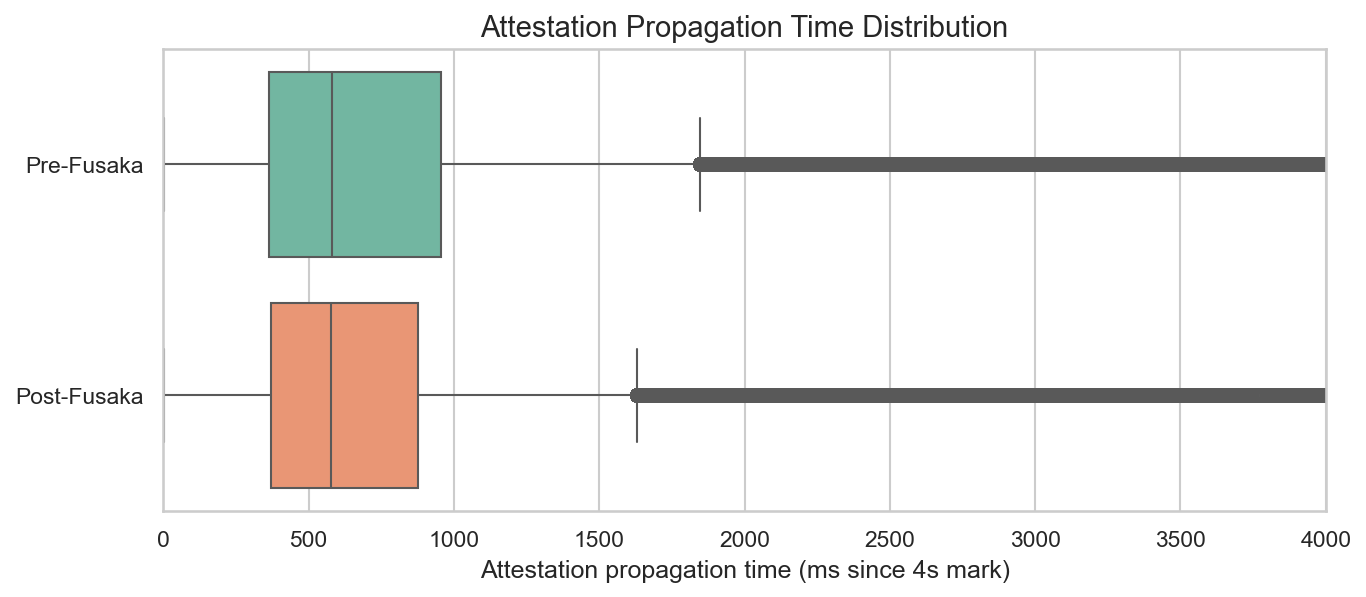

In [27]:
# Box plot comparison
plt.figure(figsize=(10, 4))
sns.boxplot(
    data=temp_df,
    x="atts_prop_time_ms",
    y="period",
    hue="period",
)
plt.title("Attestation Propagation Time Distribution")
plt.xlabel("Attestation propagation time (ms since 4s mark)")
plt.ylabel("")
plt.xlim(0, 4000)
plt.show()


## 7. Comparison by Entity


In [28]:
# Entity comparison - median propagation time
entity_stats = (
    filtered_df
    .groupby(["period", "entity"])["atts_prop_time_ms"]
    .median()
    .reset_index()
    .pivot(index="entity", columns="period", values="atts_prop_time_ms")
    .sort_values("Pre-Fusaka")
)

entity_stats["Difference (ms)"] = entity_stats["Post-Fusaka"] - entity_stats["Pre-Fusaka"]
entity_stats["Change (%)"] = ((entity_stats["Post-Fusaka"] - entity_stats["Pre-Fusaka"]) / entity_stats["Pre-Fusaka"] * 100).round(1)

entity_stats.round(1)


period,Post-Fusaka,Pre-Fusaka,Difference (ms),Change (%)
entity,,,,
blockdaemon,383.0,275.0,108.0,39.3
upbit,NaN,313.0,NaN,NaN
rocketpool,452.0,403.0,49.0,12.2
lido,468.0,404.0,64.0,15.8
okex,469.0,493.0,-24.0,-4.9
other,508.0,500.0,8.0,1.6
ether.fi,518.0,502.0,16.0,3.2
solo_stakers,593.0,525.0,68.0,13.0
stakefish,415.0,535.0,-120.0,-22.4


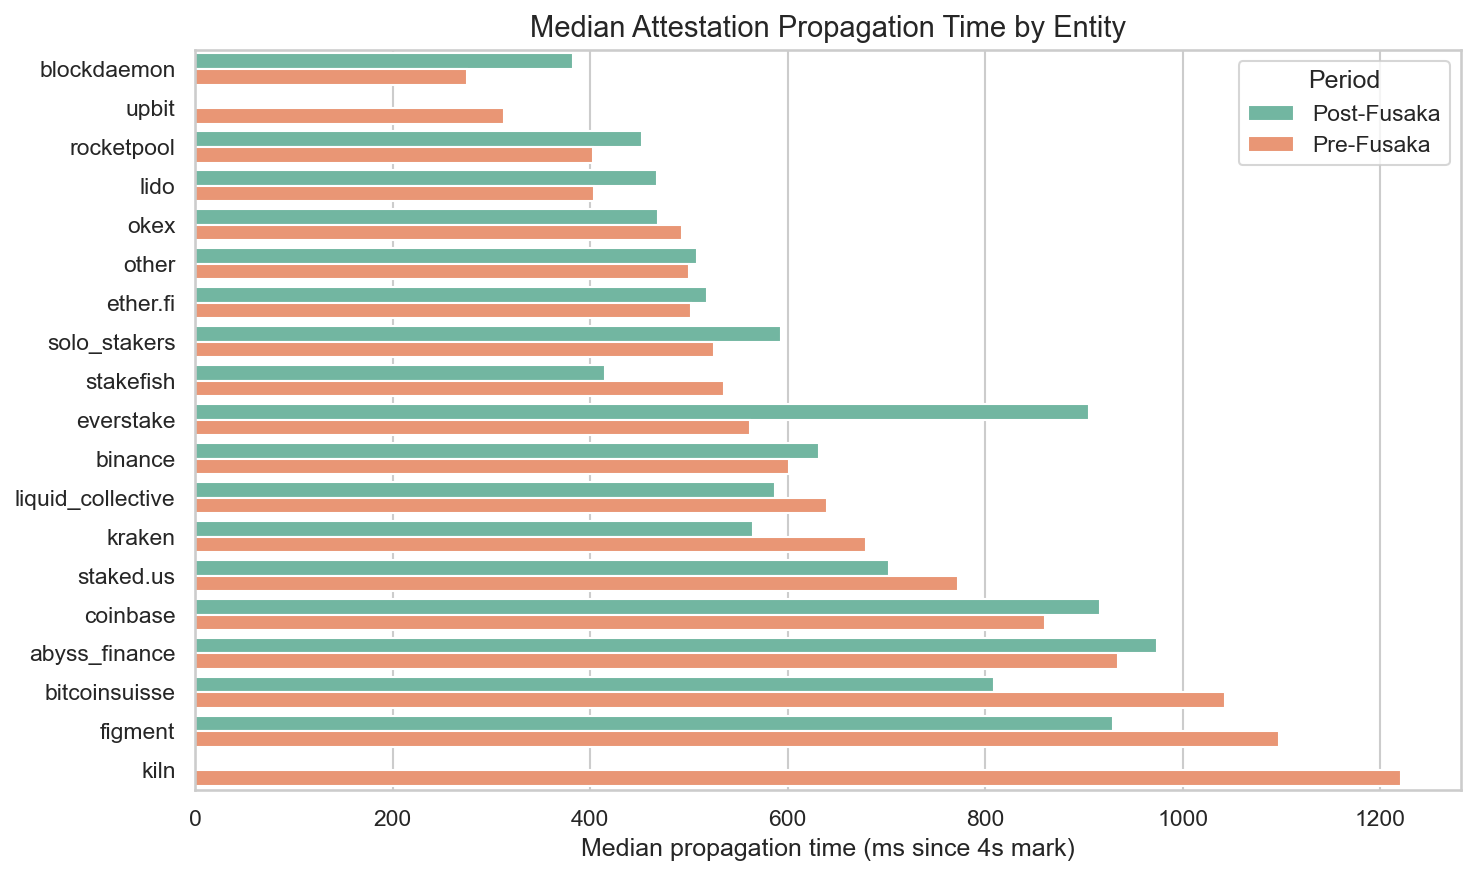

In [29]:
# Entity comparison visualization
entity_median = (
    filtered_df
    .groupby(["period", "entity"])["atts_prop_time_ms"]
    .median()
    .reset_index()
)

# Sort entities by Pre-Fusaka median
entity_order = (
    entity_median[entity_median["period"] == "Pre-Fusaka"]
    .sort_values("atts_prop_time_ms")["entity"]
    .tolist()
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=entity_median,
    x="atts_prop_time_ms",
    y="entity",
    hue="period",
    order=entity_order
)
plt.title("Median Attestation Propagation Time by Entity")
plt.xlabel("Median propagation time (ms since 4s mark)")
plt.ylabel("")
plt.legend(title="Period")
plt.tight_layout()
plt.show()


## 8. Key Percentile Comparison


In [30]:
# Key percentiles comparison
key_percentiles = [0.50, 0.66, 0.75, 0.90, 0.95, 0.99]

percentile_comparison = []
for period in ["Pre-Fusaka", "Post-Fusaka"]:
    period_df = filtered_df[filtered_df["period"] == period]
    for p in key_percentiles:
        val = period_df["atts_prop_time_ms"].quantile(p)
        percentile_comparison.append({
            "Period": period, 
            "Percentile": f"P{int(p*100)}", 
            "Time (ms)": val
        })

percentile_df = pd.DataFrame(percentile_comparison)
percentile_pivot = percentile_df.pivot(index="Percentile", columns="Period", values="Time (ms)")
percentile_pivot["Difference (ms)"] = percentile_pivot["Post-Fusaka"] - percentile_pivot["Pre-Fusaka"]
percentile_pivot["Change (%)"] = ((percentile_pivot["Post-Fusaka"] - percentile_pivot["Pre-Fusaka"]) / percentile_pivot["Pre-Fusaka"] * 100).round(1)

percentile_pivot.round(1)


Period,Post-Fusaka,Pre-Fusaka,Difference (ms),Change (%)
Percentile,,,,
P50,577.0,582.0,-5.0,-0.9
P66,742.0,776.0,-34.0,-4.4
P75,875.0,959.0,-84.0,-8.8
P90,1290.0,1436.0,-146.0,-10.2
P95,1634.0,1782.0,-148.0,-8.3
P99,2651.0,2931.0,-280.0,-9.6


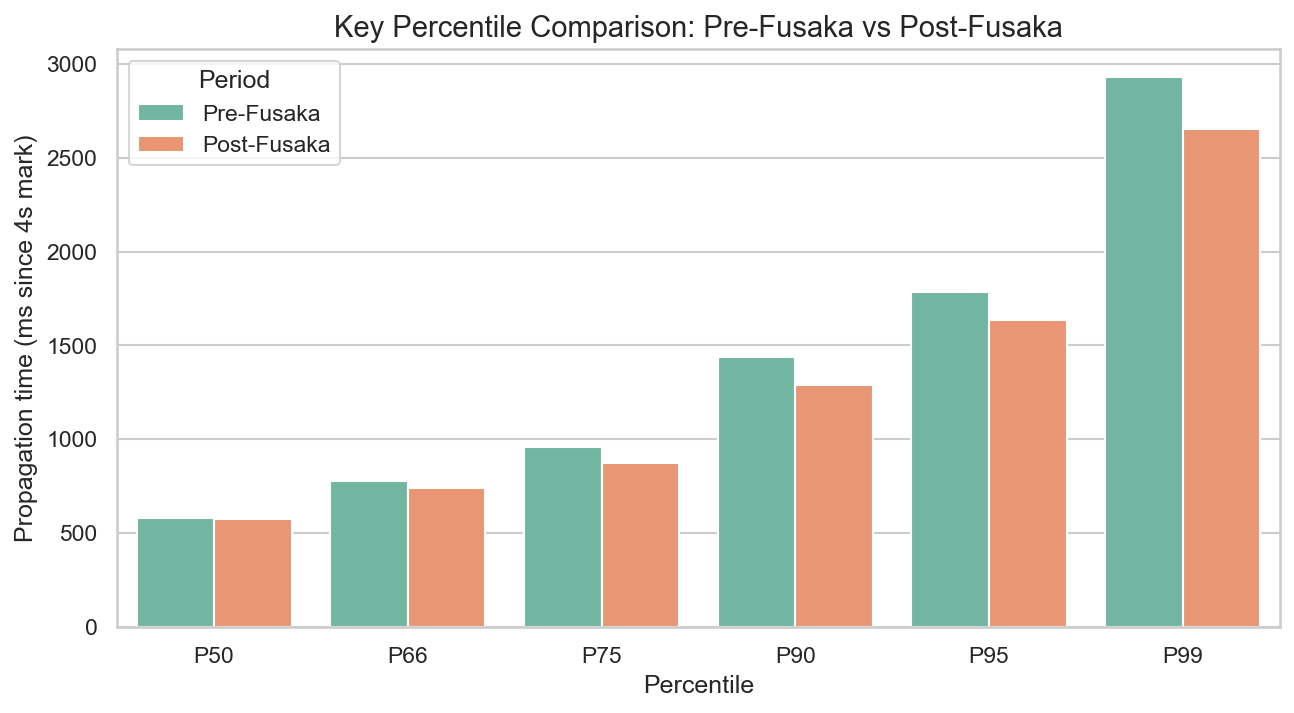

In [31]:
# Percentile comparison bar chart
plt.figure(figsize=(10, 5))
sns.barplot(
    data=percentile_df,
    x="Percentile",
    y="Time (ms)",
    hue="Period"
)
plt.title("Key Percentile Comparison: Pre-Fusaka vs Post-Fusaka")
plt.ylabel("Propagation time (ms since 4s mark)")
plt.legend(title="Period")
plt.show()


## 9. Summary


In [32]:
# Print summary comparison
print("=" * 60)
print("ATTESTATION PROPAGATION TIME COMPARISON SUMMARY")
print("=" * 60)

for period in ["Pre-Fusaka", "Post-Fusaka"]:
    period_df = filtered_df[filtered_df["period"] == period]
    print(f"\n{period}:")
    print(f"  Slots range: {period_df['slot'].min():,} - {period_df['slot'].max():,}")
    print(f"  Total attestations: {len(period_df):,}")
    print(f"  Median: {period_df['atts_prop_time_ms'].median():.1f} ms")
    print(f"  P95: {period_df['atts_prop_time_ms'].quantile(0.95):.1f} ms")

# Calculate overall change
pre_median = filtered_df[filtered_df["period"] == "Pre-Fusaka"]["atts_prop_time_ms"].median()
post_median = filtered_df[filtered_df["period"] == "Post-Fusaka"]["atts_prop_time_ms"].median()
change_pct = ((post_median - pre_median) / pre_median * 100)

print(f"\n{'=' * 60}")
print(f"Median change: {post_median - pre_median:+.1f} ms ({change_pct:+.1f}%)")
print("=" * 60)


ATTESTATION PROPAGATION TIME COMPARISON SUMMARY

Pre-Fusaka:
  Slots range: 12,344,720 - 12,394,586
  Total attestations: 2,313,595
  Median: 582.0 ms
  P95: 1782.0 ms

Post-Fusaka:
  Slots range: 13,191,851 - 13,219,663
  Total attestations: 2,359,338
  Median: 577.0 ms
  P95: 1634.0 ms

Median change: -5.0 ms (-0.9%)
